# Summary of training data

This PR shows a `BestParameterManager` that allows us to extract the best parameters found over all methods over all depths for each graphs. This summary of the best results is further stored in a json file.

In [7]:
from utils.best_parameters import BestParameterManager

Update the summary in the database. This can take a bit of time since we need to scan each result file.

In [8]:
manager = BestParameterManager()

In [9]:
manager.add_data("data/training/random_regular")
manager.add_data("data/training/heavy_hex")
manager.add_data("data/training/line_to_full")
manager.add_data("data/training/erdos_renyi")

In [10]:
manager.save_summary("data/training/best_parameters_summary.json", overwrite=True)

### If data has already been saved

We simply load the summary of the data and plot it.

In [2]:
manager = BestParameterManager("data/training/best_parameters_summary.json")

In [11]:
import matplotlib.pyplot as plt

def plot_energy(instance: dict, fig=None, axis=None, label=None):
    if fig is None or axis is None:
        fig, axis = plt.subplots(1, 1)
    
    depths = sorted([int(d) for d in instance.keys()])

    axis.plot(depths, [instance[str(key)]["energy"] for key in depths], label=label)

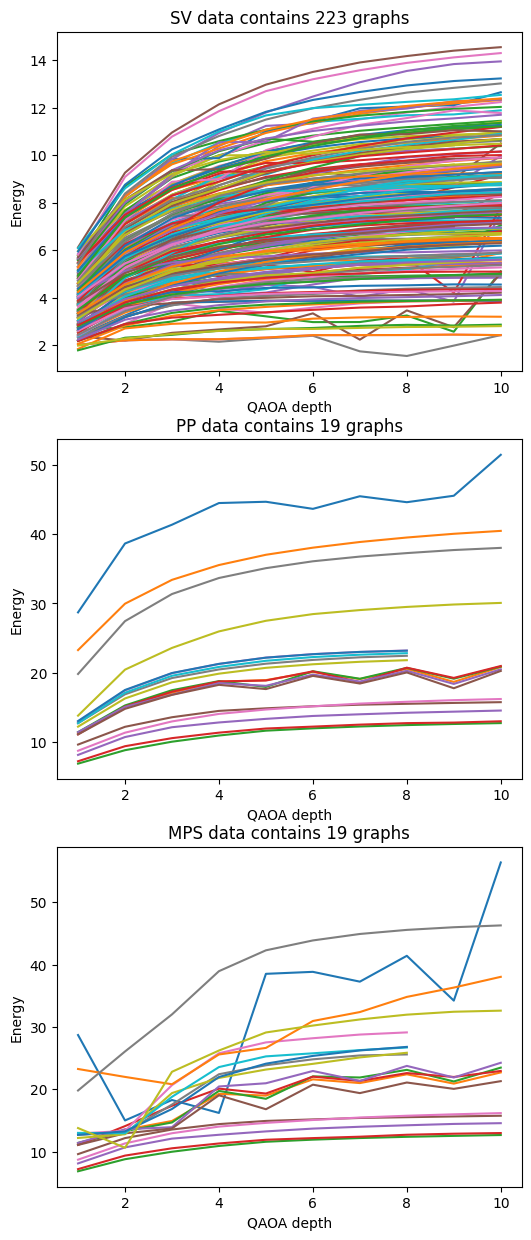

In [12]:
fig, axis = plt.subplots(3, 1, figsize=(6, 15))

for idx, method in enumerate(["SV", "PP", "MPS"]):
    instance_counter = 0
    for key, val in manager.data[method].items():
        instance_counter += 1
        plot_energy(val, fig, axis[idx], label=key)#.keys()
    
    axis[idx].set_title(f"{method} data contains {instance_counter} graphs")
    axis[idx].set_ylabel("Energy")
    axis[idx].set_xlabel("QAOA depth")
#fig.legend()

We can also filter the parameters to get those that produce monotonically increasing energies.

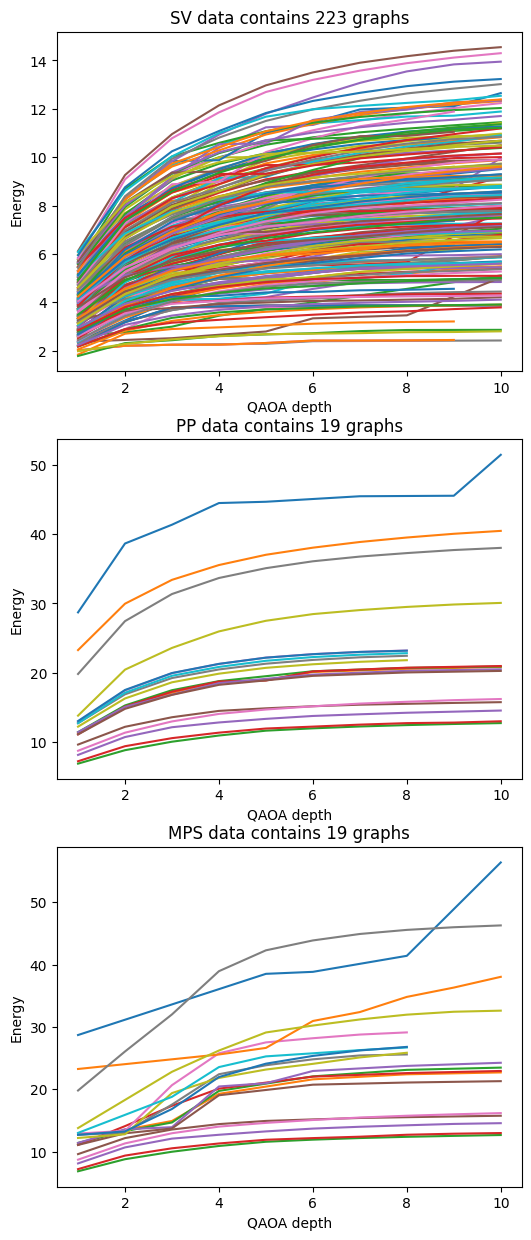

In [13]:
fig, axis = plt.subplots(3, 1, figsize=(6, 15))

monotonic_data = manager.get_monotonic_data()

for idx, method in enumerate(["SV", "PP", "MPS"]):
    instance_counter = 0
    for key, val in monotonic_data[method].items():
        instance_counter += 1
        plot_energy(val, fig, axis[idx], label=key)#.keys()
    
    axis[idx].set_title(f"{method} data contains {instance_counter} graphs")
    axis[idx].set_ylabel("Energy")
    axis[idx].set_xlabel("QAOA depth")